<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/YOLOv8_Pascal_VOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import shutil
import random
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# DOWNLOAD DATASET

In [2]:
!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d huanghanchina/pascal-voc-2012

!unzip -q /content/pascal-voc-2012.zip -d /content/dataset/

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/huanghanchina/pascal-voc-2012
License(s): DbCL-1.0
100% 3.63G/3.63G [03:32<00:00, 18.3MB/s]



# CLASS NAMES

In [3]:
classes = [
    'aeroplane',
    'bicycle',
    'bird',
    'boat',
    'bottle',
    'bus',
    'car',
    'cat',
    'chair',
    'cow',
    'diningtable',
    'dog',
    'horse',
    'motorbike',
    'person',
    'pottedplant',
    'sheep',
    'sofa',
    'train',
    'tvmonitor'
]

class_dict = {
    name:i for i, name in enumerate(classes)
}


# ORIGINAL DATASET PATHS

In [4]:
IMAGE_DIR = "/content/dataset/VOC2012/JPEGImages"
ANNOTATION_DIR = "/content/dataset/VOC2012/Annotations"

# CREATE YOLO DATASET STRUCTURE

In [5]:
YOLO_DIR = "/content/yolo_dataset"

TRAIN_IMAGES_DIR = f"{YOLO_DIR}/images/train"
VAL_IMAGES_DIR   = f"{YOLO_DIR}/images/val"

TRAIN_LABELS_DIR = f"{YOLO_DIR}/labels/train"
VAL_LABELS_DIR   = f"{YOLO_DIR}/labels/val"

# Remove old dataset if exists

if os.path.exists(YOLO_DIR):
    shutil.rmtree(YOLO_DIR)

# Create folders

os.makedirs(TRAIN_IMAGES_DIR, exist_ok=True)
os.makedirs(VAL_IMAGES_DIR, exist_ok=True)

os.makedirs(TRAIN_LABELS_DIR, exist_ok=True)
os.makedirs(VAL_LABELS_DIR, exist_ok=True)


# TRAIN / VALIDATION SPLIT

In [6]:
all_images = glob.glob(
    os.path.join(IMAGE_DIR, "*.jpg")
)

random.shuffle(all_images)

split_ratio = 0.1

val_size = int(len(all_images) * split_ratio)

val_images = all_images[:val_size]

train_images = all_images[val_size:]

print("Train Images:", len(train_images))
print("Validation Images:", len(val_images))

Train Images: 15413
Validation Images: 1712


# VOC XML → YOLO TXT CONVERTER

In [7]:
def convert_voc_to_yolo(xml_file, output_file):

    tree = ET.parse(xml_file)

    root = tree.getroot()

    size = root.find("size")

    width  = int(size.find("width").text)
    height = int(size.find("height").text)

    with open(output_file, "w") as f:

        for obj in root.findall("object"):

            class_name = obj.find("name").text

            if class_name not in class_dict:
                continue

            class_id = class_dict[class_name]

            bbox = obj.find("bndbox")

            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            x_center = ((xmin + xmax) / 2) / width
            y_center = ((ymin + ymax) / 2) / height

            box_width  = (xmax - xmin) / width
            box_height = (ymax - ymin) / height

            f.write(
                f"{class_id} "
                f"{x_center} "
                f"{y_center} "
                f"{box_width} "
                f"{box_height}\n"
            )

# COPY TRAIN DATA

In [8]:
for image_path in train_images:

    image_name = os.path.basename(image_path)

    xml_name = image_name.replace(".jpg", ".xml")

    xml_path = os.path.join(
        ANNOTATION_DIR,
        xml_name
    )

    # Copy image

    shutil.copy(
        image_path,
        os.path.join(
            TRAIN_IMAGES_DIR,
            image_name
        )
    )

    # Create label

    output_label = os.path.join(
        TRAIN_LABELS_DIR,
        image_name.replace(".jpg", ".txt")
    )

    convert_voc_to_yolo(
        xml_path,
        output_label
    )

print("Train dataset prepared")

Train dataset prepared


# COPY VALIDATION DATA

In [9]:
for image_path in val_images:

    image_name = os.path.basename(image_path)

    xml_name = image_name.replace(".jpg", ".xml")

    xml_path = os.path.join(
        ANNOTATION_DIR,
        xml_name
    )

    # Copy image

    shutil.copy(
        image_path,
        os.path.join(
            VAL_IMAGES_DIR,
            image_name
        )
    )

    # Create label

    output_label = os.path.join(
        VAL_LABELS_DIR,
        image_name.replace(".jpg", ".txt")
    )

    convert_voc_to_yolo(
        xml_path,
        output_label
    )

print("Validation dataset prepared")

Validation dataset prepared


# VERIFY DATASET

In [10]:
print("\nTrain Images:",
      len(os.listdir(TRAIN_IMAGES_DIR)))

print("Train Labels:",
      len(os.listdir(TRAIN_LABELS_DIR)))

print("Validation Images:",
      len(os.listdir(VAL_IMAGES_DIR)))

print("Validation Labels:",
      len(os.listdir(VAL_LABELS_DIR)))


Train Images: 15413
Train Labels: 15413
Validation Images: 1712
Validation Labels: 1712


# CREATE YAML CONFIG FILE

In [11]:
data_yaml = {

    'path': YOLO_DIR,

    'train': 'images/train',

    'val': 'images/val',

    'names': {
        i: classes[i]
        for i in range(len(classes))
    }
}

yaml_path = f"{YOLO_DIR}/data.yaml"

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print("\nYAML file created")


YAML file created


# LOAD YOLOv8 MODEL

In [12]:
model = YOLO("yolov8n.pt")

# TRAIN MODEL

In [13]:
results = model.train(

    data=yaml_path,

    epochs=10,

    imgsz=640,

    batch=16,

    #device=0,      # GPU

    workers=2,

    patience=20,

    save=True,

    project="/content/runs",

    name="yolov8_pascal_voc"

)


Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_pascal_voc, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

# VALIDATION

In [14]:
#model = load_model('C:\Users\roton\Downloads\yolov8n.pt')

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3255019678.py, line 1)

In [15]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1530.2±972.5 MB/s, size: 107.6 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 1712 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1712/1712 448.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 6.5it/s 16.4s
                   all       1712       4061      0.714      0.613       0.68      0.511
             aeroplane         57         73      0.853      0.767      0.822       0.56
               bicycle         60         87      0.691      0.517      0.638       0.48
                  bird         89        145      0.871      0.683      0.764      0.534
                  boat         59        130      0.734      0.454      0.556      0.363
                bottle         77     

# PERFORMANCE GRAPHS

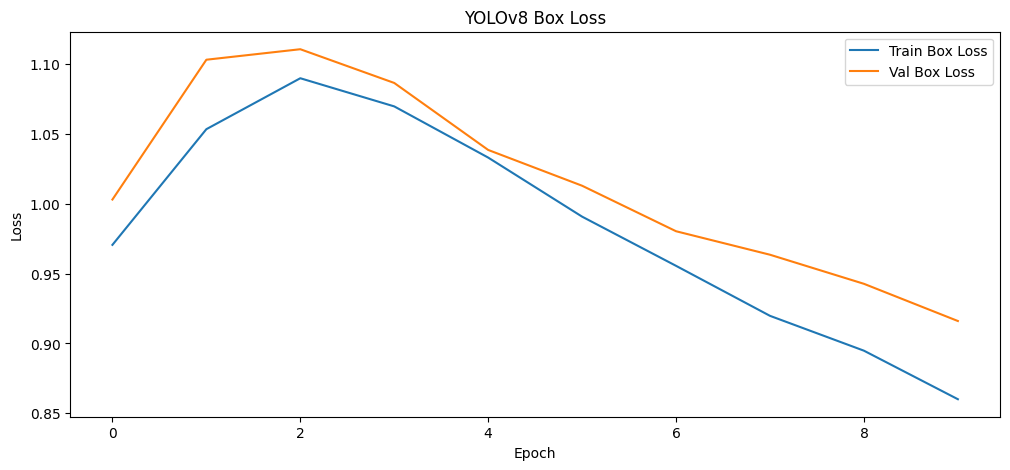

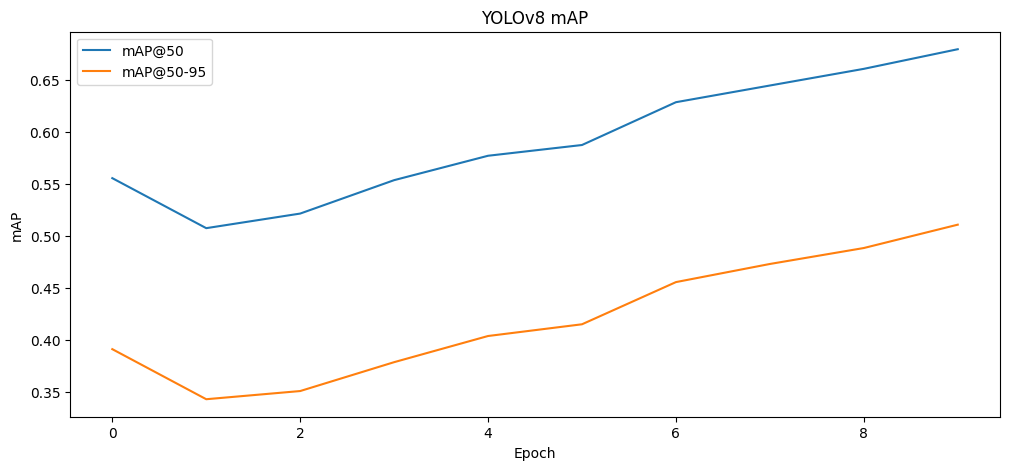

In [16]:
results_csv = "/content/runs/yolov8_pascal_voc/results.csv"

import pandas as pd

df = pd.read_csv(results_csv)

# ---------------- LOSS GRAPH ----------------

plt.figure(figsize=(12,5))

plt.plot(df['train/box_loss'], label='Train Box Loss')

plt.plot(df['val/box_loss'], label='Val Box Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("YOLOv8 Box Loss")

plt.legend()

plt.show()

# ---------------- mAP GRAPH ----------------

plt.figure(figsize=(12,5))

plt.plot(
    df['metrics/mAP50(B)'],
    label='mAP@50'
)

plt.plot(
    df['metrics/mAP50-95(B)'],
    label='mAP@50-95'
)

plt.xlabel("Epoch")

plt.ylabel("mAP")

plt.title("YOLOv8 mAP")

plt.legend()

plt.show()

# TEST IMAGE

In [28]:
test_image = random.choice(val_images)

print("Test Image:", test_image)

Test Image: /content/dataset/VOC2012/JPEGImages/2010_005119.jpg


In [29]:
prediction = model.predict(

    source=test_image,

    conf=0.3,

    save=True,

    line_width=2

)


image 1/1 /content/dataset/VOC2012/JPEGImages/2010_005119.jpg: 448x640 1 car, 41.2ms
Speed: 2.4ms preprocess, 41.2ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


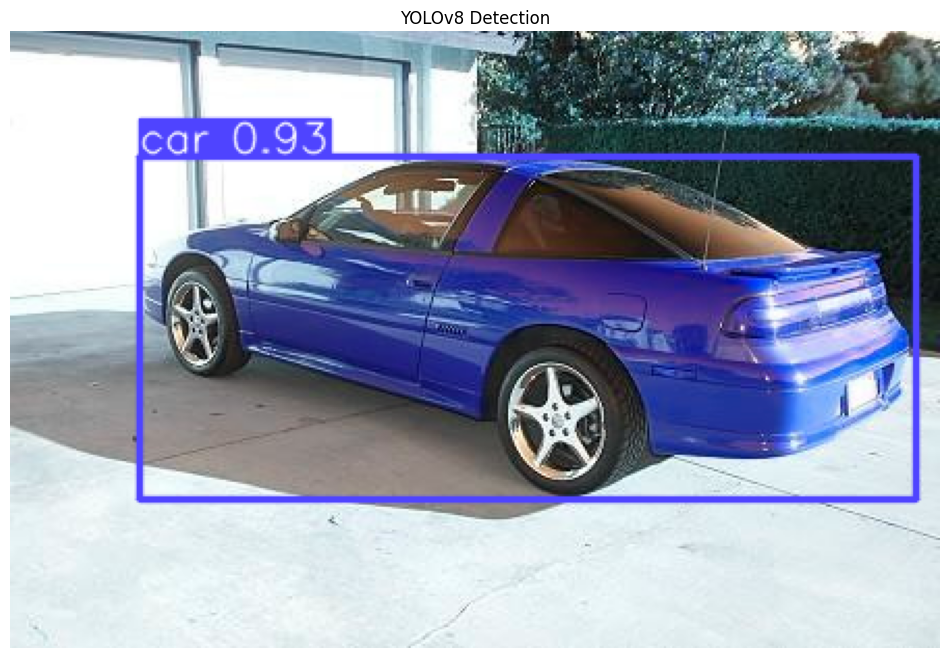

In [30]:
result_image = prediction[0].plot()

plt.figure(figsize=(12,12))

plt.imshow(result_image)

plt.axis("off")

plt.title("YOLOv8 Detection")

plt.show()

# SAVE MODEL

In [31]:
model.export(format="onnx")

print("\nONNX model exported")

Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/yolov8_pascal_voc/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 24, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 272ms
Prepared 4 packages in 7.26s
Installed 4 packages in 274ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 8.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 10.5s, saved as '/conten

# SAVE PYTORCH MODEL

In [32]:
model.save("/content/yolov8_pascal_voc.pt")

print("\nModel saved successfully")


Model saved successfully
